# Model Test (JAX): Per-Feature Pseudocoherence Likelihood

Testing the model in a toy case:
- 5 (fake) training features, their 2D embeddings, and corresponding utterances.
- 3 (fake) generalization features at different locations. (one close to generic, one spec, one between)
- calculate candidate pseudocoherences and compute log-likelihood, then show the posterior predictions.

Same as test_model.ipynb but using JAX arrays and BlackJAX. No U-Turn Sampling jointly samples training and test pseudocoherences.

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from model_jax import log_likelihood, make_log_density_fn

## Training Data Definitions

Same toy data as `test_model.ipynb`.  
Utterances encoded as integers: 0=generic, 1=specific.  
Pseudocoherences `y_vec` still hardcoded for the grid sweep; MCMC cell treats them as latent.

In [2]:
# 2D embeddings of training features
x_vec = jnp.array([
    [0.8, 0.9],   # feature 1 — top-right cluster
    [0.9, 0.7],   # feature 2 — top-right cluster
    [0.1, 0.2],   # feature 3 — bottom-left
    [0.5, 0.1],   # feature 4 — bottom-center
    [0.2, 0.8],   # feature 5 — top-left
])

# Utterances: 0=generic, 1=specific
u_vec = jnp.array([0, 0, 1, 1, 0], dtype=jnp.int32)

# Known pseudocoherences for training features (hardcoded for grid sweep testing)
y_vec = jnp.array([1.5, 1.2, -1.0, -0.8, 0.9])

params = {
    'mu_0':         0.0,
    'length_scale': 0.4,
    'output_scale': 1.5,
    'beta':         3.0,
}

# 3 generalization features at new 2D locations
x_gen = jnp.array([
    [0.85, 0.8],  # gen A — near the generic cluster
    [0.3,  0.15], # gen B — near the specific cluster
    [0.5,  0.5],  # gen C — in the middle
])
gen_labels = ["A (near generics)", "B (near specifics)", "C (middle)"]

## Grid Sweep: Posterior over y' (equivalence check with NumPy version)

Treats `y_vec` as known (same as original notebook). Sweeps over candidate `y'` values and normalizes to get an approximate posterior.

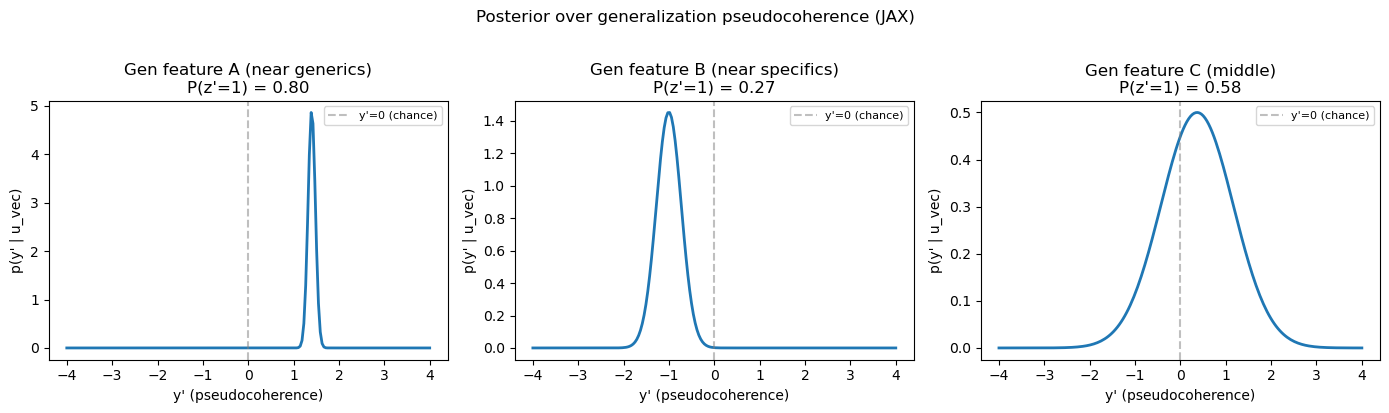

In [3]:
y_grid = jnp.linspace(-4, 4, 200)
dy = float(y_grid[1] - y_grid[0])

training_data = {
    'utt_types':  u_vec,
    'features':   x_vec,
    'coherences': y_vec,
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

p_generic = []  # P(z'=1 | u_vec) for each gen feature

for ax, x_prime, label in zip(axes, x_gen, gen_labels):
    log_lik_fn = jax.jit(jax.vmap(
        lambda y_p: log_likelihood(
            training_data,
            {'feature': x_prime, 'coherence': y_p},
            params,
        )
    ))
    log_liks = np.array(log_lik_fn(y_grid))

    log_posterior = log_liks - logsumexp(log_liks)
    posterior = np.exp(log_posterior)
    posterior /= posterior.sum() * dy

    # E[sigmoid(y')] under posterior = P(z'=1 | u_vec)
    p_z1 = float(np.sum(np.array(jax.nn.sigmoid(y_grid)) * posterior) * dy)
    p_generic.append(p_z1)

    ax.plot(np.array(y_grid), posterior, lw=2)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5, label="y'=0 (chance)")
    ax.set_title(f"Gen feature {label}\nP(z'=1) = {p_z1:.2f}")
    ax.set_xlabel("y' (pseudocoherence)")
    ax.set_ylabel("p(y' | u_vec)")
    ax.legend(fontsize=8)

plt.suptitle("Posterior over generalization pseudocoherence (JAX)", y=1.02)
plt.tight_layout()
plt.show()

## Visualize the 2D Embedding Space

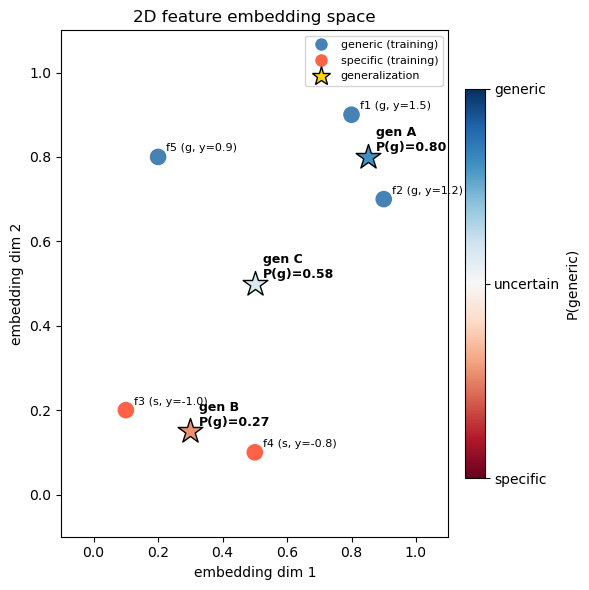

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))

utt_labels = ["generic", "generic", "specific", "specific", "generic"]
colors = ["steelblue" if u == "generic" else "tomato" for u in utt_labels]
x_vec_np = np.array(x_vec)
y_vec_np = np.array(y_vec)
ax.scatter(x_vec_np[:, 0], x_vec_np[:, 1], c=colors, s=120, zorder=3)

for i, (x, y_val, u) in enumerate(zip(x_vec_np, y_vec_np, utt_labels)):
    ax.annotate(f"f{i+1} ({u[0]}, y={y_val:.1f})", xy=(x[0], x[1]),
                xytext=(6, 4), textcoords="offset points", fontsize=8)

cmap = plt.cm.RdBu
for xp, lbl, p_z1 in zip(np.array(x_gen), ["A", "B", "C"], p_generic):
    star_color = cmap(p_z1)
    ax.scatter(*xp, marker="*", s=350, color=star_color, edgecolors="black", zorder=4)
    ax.annotate(f"gen {lbl}\nP(g)={p_z1:.2f}", xy=(xp[0], xp[1]),
                xytext=(6, 4), textcoords="offset points", fontsize=9, fontweight="bold")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("P(generic)")
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["specific", "uncertain", "generic"])

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='generic (training)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato', markersize=10, label='specific (training)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markeredgecolor='black', markersize=14, label='generalization'),
]
ax.legend(handles=legend_elements, fontsize=8)
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel("embedding dim 1")
ax.set_ylabel("embedding dim 2")
ax.set_title("2D feature embedding space")
plt.tight_layout()
plt.show()

## BlackJAX NUTS: Joint Sampling of Pseudocoherences

Here we treat both `y_vec` (training pseudocoherences) and `y'` (test pseudocoherence) as latent
and sample them jointly. This is the proper Bayesian inference — no hardcoded `y_vec` needed.

The position PyTree is:
```
position = {
    'training_coherences': shape (n,),
    'test_coherence':      scalar
}
```

In [17]:
import blackjax

# Use generalization feature A as the test feature
x_prime = x_gen[2]

log_density_fn = make_log_density_fn(
    training_utt_types=u_vec,
    training_features=x_vec,
    test_feature=x_prime,
    params=params,
)

n_train = x_vec.shape[0]
init_position = {
    'training_coherences': jnp.zeros(n_train),
    'test_coherence':      jnp.array(0.0),
}

# Verify log_density is finite at init
print("log_density at init:", log_density_fn(init_position))

# BlackJAX NUTS setup
rng_key = jax.random.PRNGKey(0)
warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
rng_key, warmup_key = jax.random.split(rng_key)
(state, parameters), _ = warmup.run(warmup_key, init_position, num_steps=500)
print("Warmup complete. Step size:", parameters['step_size'])

log_density at init: -9.762111
Warmup complete. Step size: 0.3840722


In [18]:
# Draw samples
nuts = blackjax.nuts(log_density_fn, **parameters)

@jax.jit
def one_step(state, rng_key):
    return nuts.step(rng_key, state)

n_samples = 100000
keys = jax.random.split(rng_key, n_samples)
states = []
for key in keys:
    state, info = one_step(state, key)
    states.append(state.position)

test_coherences = np.array([s['test_coherence'] for s in states])
train_coherences = np.array([s['training_coherences'] for s in states])  # (n_samples, n_train)

# P(z'=1 | u_vec) = E[sigmoid(y')]
p_z1_mcmc = float(np.mean(jax.nn.sigmoid(test_coherences)))
print(f"P(z'=1 | u_vec) [MCMC, gen A]: {p_z1_mcmc:.3f}")
print(f"P(z'=1 | u_vec) [grid sweep]:  {p_generic[0]:.3f}")

P(z'=1 | u_vec) [MCMC, gen A]: 0.540
P(z'=1 | u_vec) [grid sweep]:  0.802


/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_78218/1985133843.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(train_coherences, labels=[f"f{i+1}" for i in range(n_train)])


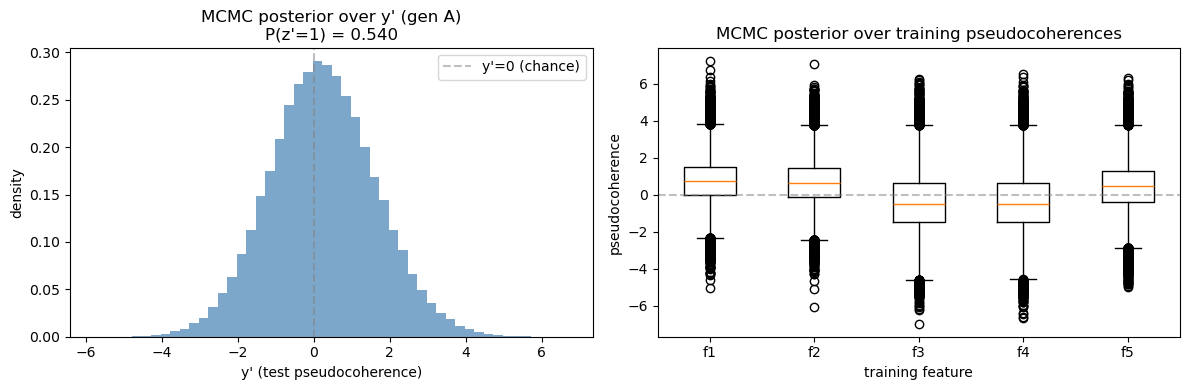

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(test_coherences, bins=50, density=True, color='steelblue', alpha=0.7)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5, label="y'=0 (chance)")
axes[0].set_xlabel("y' (test pseudocoherence)")
axes[0].set_ylabel("density")
axes[0].set_title(f"MCMC posterior over y' (gen A)\nP(z'=1) = {p_z1_mcmc:.3f}")
axes[0].legend()

axes[1].boxplot(train_coherences, labels=[f"f{i+1}" for i in range(n_train)])
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel("training feature")
axes[1].set_ylabel("pseudocoherence")
axes[1].set_title("MCMC posterior over training pseudocoherences")

plt.tight_layout()
plt.show()